In [19]:
from pathlib import Path

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
from outliers import smirnov_grubbs as grubbs

In [21]:
import stumpy
from sktime.transformations.panel.matrix_profile import MatrixProfile

In [22]:
sns.set_theme(context='notebook', style='whitegrid', palette='muted', rc={'figure.figsize': (12, 6)})

In [23]:
data_dir = Path('../../results')
train = pd.read_csv(data_dir / 'train_ts.csv', index_col='id')

In [24]:
train_X = train[[str(i) for i in range(100)]]
train_X = train_X.reset_index().melt(id_vars='id', var_name='time')
train_X['time'] = train_X['time'].astype(int)
train_X = train_X.set_index(['id', 'time'])

In [25]:
shape_medoids = ['tt7605074', 'tt1392190', 'tt2024544', 'tt0810819']
structure_medoids = ['tt2024544', 'tt1798709', 'tt3416828', 'tt1179933']

In [26]:
train.iloc[:, :12].loc[shape_medoids]

,title,startYear,runtimeMinutes,numVotes,countryOfOrigin,awardsOrNominations,awards,nominations,rating,genre,rating_category,totalGrossIncome
id,,,,,,,,,,,,
tt7605074,The Wandering Earth,2019,125,38453,['CN'],True,39.0,40.0,5.9,"['Action', 'Adventure', 'Sci-Fi']",Medium,11715373.0
tt1392190,Mad Max: Fury Road,2015,120,1177539,"['AU', 'US']",True,245.0,234.0,8.1,"['Action', 'Adventure', 'Sci-Fi']",High,289773789.0
tt2024544,12 Years a Slave,2013,134,770412,"['GB', 'US']",True,244.0,338.0,8.1,"['Biography', 'Drama', 'History']",High,69357605.0
tt0810819,The Danish Girl,2015,119,204330,"['GB', 'US', 'DE', 'DK', 'BE', 'JP']",True,32.0,82.0,7.1,"['Biography', 'Drama']",High,16716240.0


## Visualize motifs and discords on clustering medoids

In [27]:
def get_title(movie_id):
    title = train.loc[movie_id, 'title']
    year = train.loc[movie_id, 'startYear']
    return f'{title} ({year})'

In [28]:
m = 8

In [29]:
transformer = MatrixProfile(m=m)

In [30]:
%%time
mp = transformer.fit_transform(train_X)

CPU times: user 10.7 s, sys: 5.44 ms, total: 10.7 s
Wall time: 10.7 s


In [31]:
mp.index = train.index
mp.shape

(850, 93)

We consider discords only sequences classified as outliers in the profile matrix by a one sided grubb's test.

In [32]:
def get_discords(matrix_profile, alpha=0.05):
    """Detect candidate discords performing one-sided Grubb's test on matrix profile"""
    return grubbs.max_test_indices(matrix_profile, alpha=alpha)

In [33]:
def plot_ts_and_matrix_profile(movie_id):
    _, axs = plt.subplots(2, sharex=True)

    ts = train_X.loc[movie_id].value
    matrix = mp.loc[movie_id]

    # Plot raw time series
    axs[0].plot(ts)
    axs[0].set_title(get_title(movie_id))
    axs[0].set_ylabel('Box office')

    # Plot matrix profile
    axs[1].plot(matrix)
    axs[1].set_ylabel('Matrix Profile')
    plt.xticks(np.arange(0, 100, 7))

    plt.xlim((0, len(ts)))

    return axs

In [34]:
def plot_motifs(movie_id, axs, max_motifs=1):
    matrix = mp.loc[movie_id]
    ts = train_X.loc[movie_id]['value']
    bottom, top = axs[0].get_ylim()

    _, motif_idxs = stumpy.motifs(ts, matrix, max_motifs=max_motifs)

    for i, motif in enumerate(motif_idxs):
        color = 'C1' if max_motifs < 1 else f'C{i}'
        for starttime in motif:
            rect = Rectangle((starttime, bottom), m, top, facecolor=color, alpha=.5)
            axs[0].add_patch(rect)


In [35]:
def plot_discords(movie_id, axs, discords=None):
    matrix = mp.loc[movie_id]
    bottom, top = axs[0].get_ylim()

    # Get discords if they were not passed to the function
    if not discords:
        discords = get_discords(matrix)

    for starttime in discords:
        rect = Rectangle((starttime, bottom), m, top, facecolor='r', alpha=.5)
        axs[0].add_patch(rect)
        axs[1].axvline(x=starttime, linestyle='dashed', c='r')

### Shape-based clustering medoids

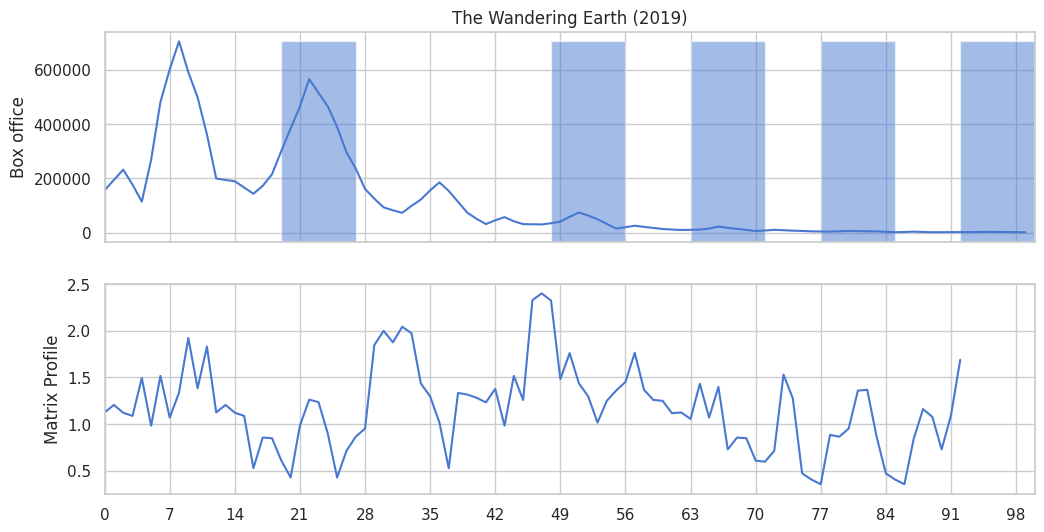

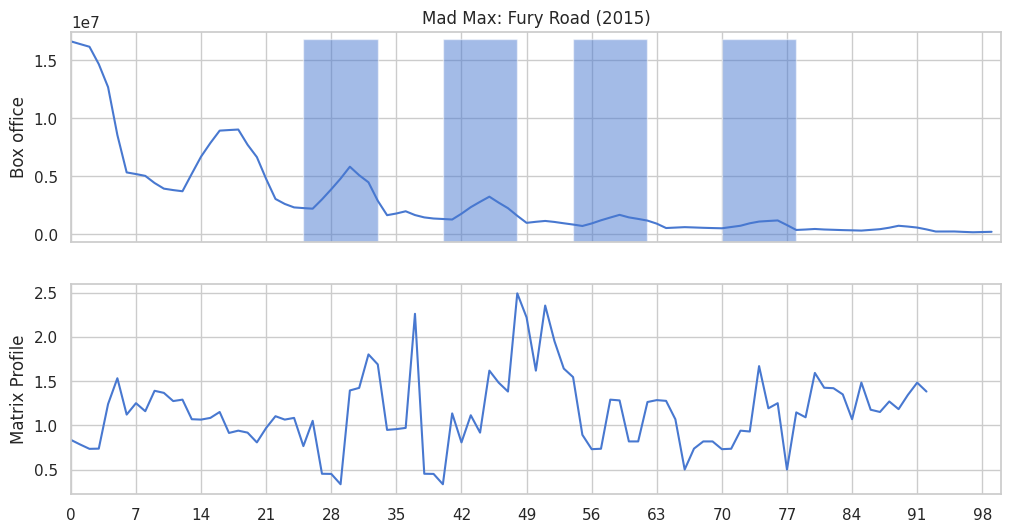

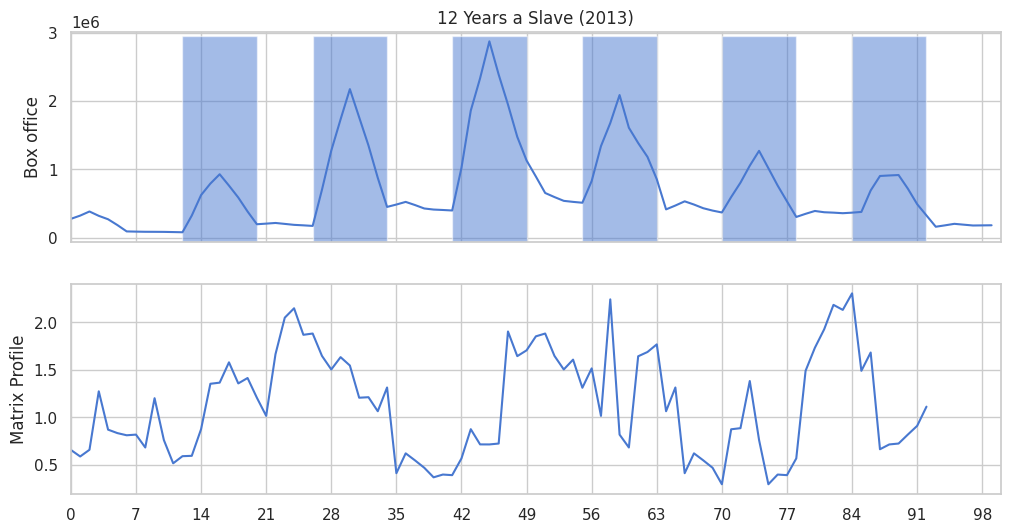

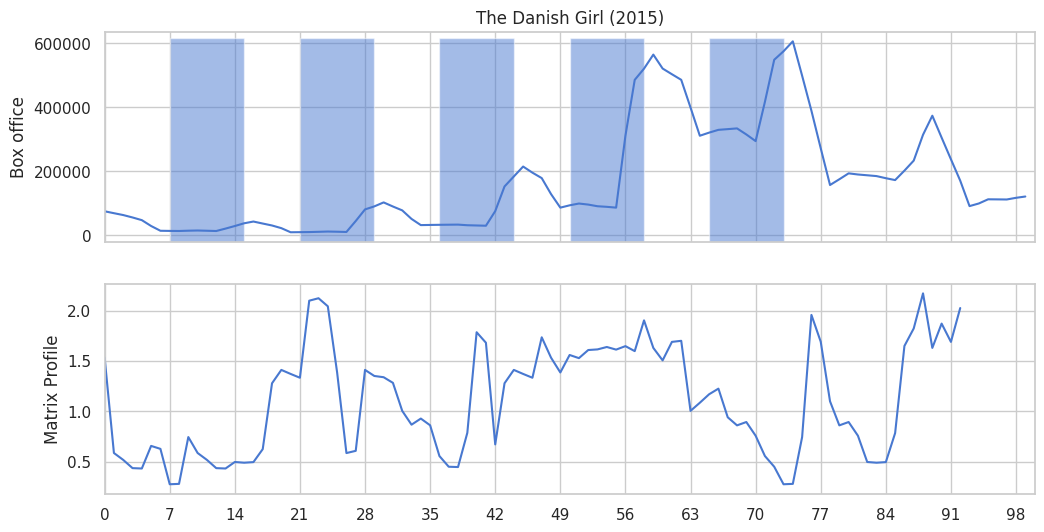

In [36]:
for movie_id in shape_medoids:
    axs = plot_ts_and_matrix_profile(movie_id)
    plot_motifs(movie_id, axs)
    plot_discords(movie_id, axs)
    plt.show()

### Structural features-based clustering medoids

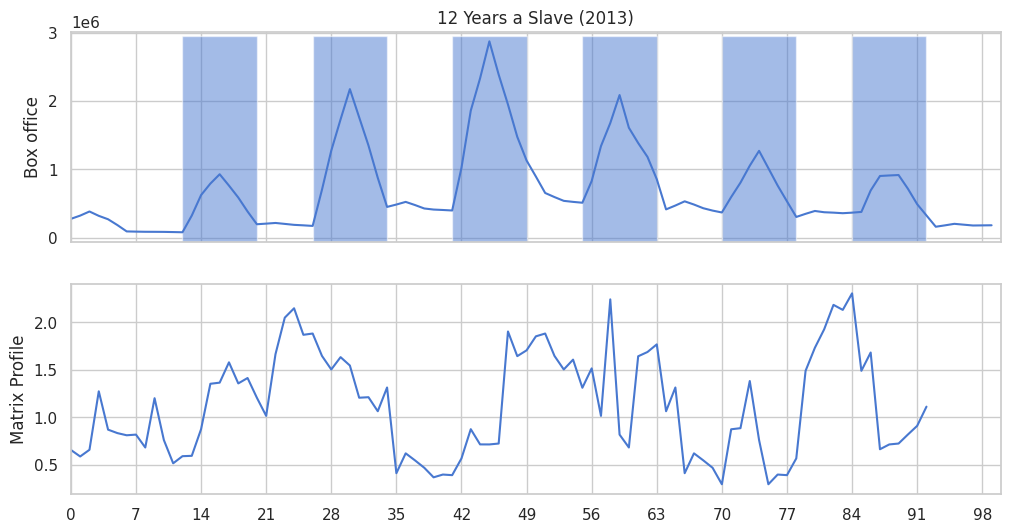

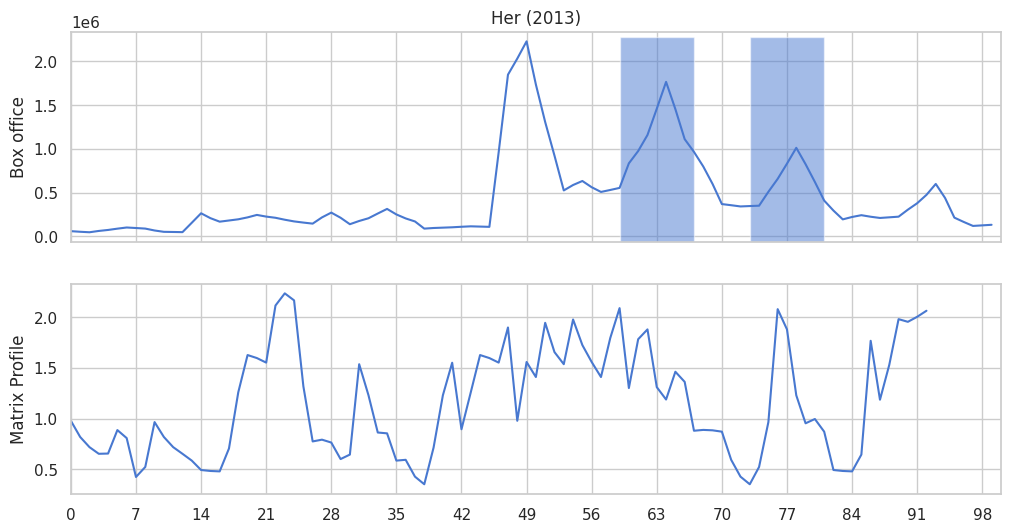

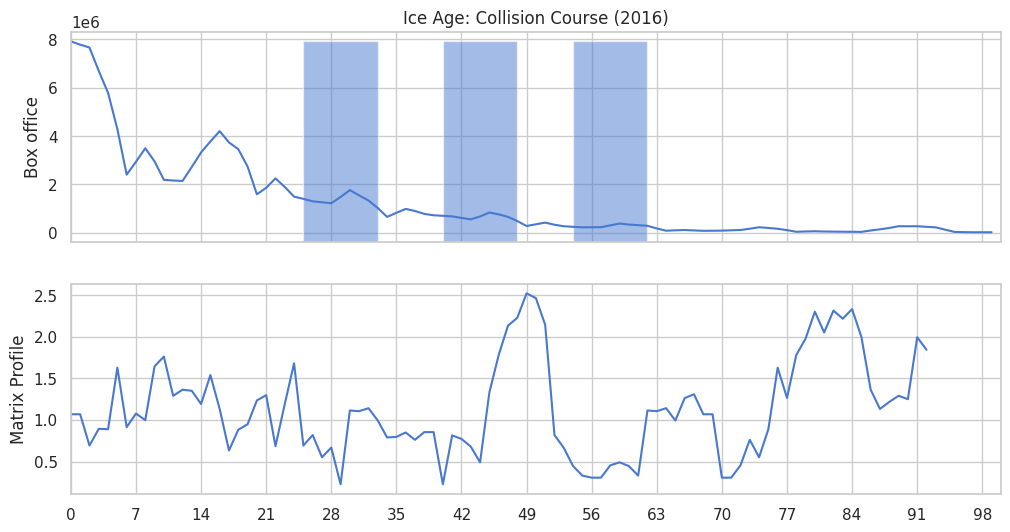

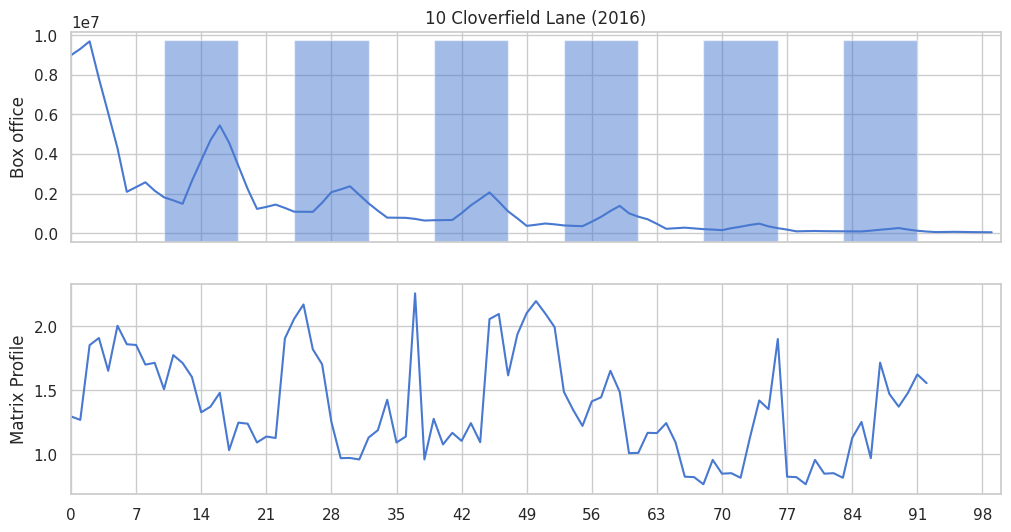

In [37]:
for movie_id in structure_medoids:
    axs = plot_ts_and_matrix_profile(movie_id)
    plot_motifs(movie_id, axs)
    plot_discords(movie_id, axs)
    plt.show()

## Search for discords in the entire dataset

In [ ]:
%%time
ts_with_discords = []

for ts in mp.index:
    matrix_profile = mp.loc[ts].values
    ts_discords = get_discords(matrix_profile)
    if ts_discords:
        ts_with_discords.append((ts, ts_discords))



CPU times: user 113 ms, sys: 2.05 ms, total: 115 ms
Wall time: 111 ms


In [47]:
len(ts_with_discords)
train.loc[[idx for idx, _ in ts_with_discords]].iloc[:,:13].sort_values('numVotes', ascending=False).head()

,title,startYear,runtimeMinutes,numVotes,countryOfOrigin,awardsOrNominations,awards,nominations,rating,genre,rating_category,totalGrossIncome,awardsRatio
id,,,,,,,,,,,,,
tt0993846,The Wolf of Wall Street,2013,180,1711865,['US'],True,38.0,180.0,8.2,"['Biography', 'Comedy', 'Crime']",High,215025286.0,0.174312
tt1392190,Mad Max: Fury Road,2015,120,1177539,"['AU', 'US']",True,245.0,234.0,8.1,"['Action', 'Adventure', 'Sci-Fi']",High,289773789.0,0.511482
tt6644200,A Quiet Place,2018,90,636617,['US'],True,38.0,129.0,7.5,"['Drama', 'Horror', 'Sci-Fi']",High,350007948.0,0.227545
tt1840309,Divergent,2014,139,509170,['US'],True,7.0,11.0,6.6,"['Action', 'Adventure', 'Drama']",Medium High,278495058.0,0.388889
tt0437086,Alita: Battle Angel,2019,122,315371,"['JP', 'CA', 'US']",True,10.0,25.0,7.3,"['Action', 'Adventure', 'Sci-Fi']",High,166601065.0,0.285714
